# Rosenbrock — MCMC Sanity Check

A minimal end-to-end sampling test on the classic Rosenbrock density, using `jax_fli`'s
preconditioned-uniform reparameterisation and batched NUTS sampling — a quick correctness check
before moving to full-field inference.

In [1]:
import arviz_base as azb
import arviz_stats as azs
import jax
import numpy as np
import numpyro

from jax_fli.infer import PreconditionnedUniform, analyze, batched_sampling, plot_posterior
from jax_fli.io import CatalogExtract

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.
JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


In [2]:
def rosenbrock_model(a=1.0, b=100.0):
    """
    Rosenbrock density bounded within a preconditioned Uniform space.
    """
    x = numpyro.sample("x", PreconditionnedUniform(low=-5.0, high=5.0))
    y = numpyro.sample("y", PreconditionnedUniform(low=-5.0, high=5.0))

    log_prob = -((a - x) ** 2 + b * (y - x**2) ** 2)

    numpyro.factor("rosenbrock_density", log_prob)

In [3]:
path = "rosenbrock_samples_nuts"
key = jax.random.key(0)
num_warmup = 1000
num_samples = 2000
batch_count = 5
chain_count = 5
sampler = "NUTS"  # or "NUTS"
mclmc_desired_energy_var = 1e-7
mclmc_initial_step_size = 1e-8
target_accept = 0.8
max_num_doublings = 10

for i in range(chain_count):
    chain_key = jax.random.fold_in(key, i)
    batched_sampling(
        rosenbrock_model,
        path=f"{path}/chain_{i}",
        rng_key=chain_key,
        num_warmup=num_warmup,
        num_samples=num_samples,
        batch_count=batch_count,
        sampler=sampler,
        progress_bar=True,
        mclmc_desired_energy_var=mclmc_desired_energy_var,
        mclmc_init_step_size_scale=mclmc_initial_step_size,
        target_accept=target_accept,
        max_num_doublings=max_num_doublings,
    )

Tuning NUTS parameters (step size and inverse mass matrix) with 1000 warmup steps...
  ==> max_num_doublings=10, target_accept=0.8
Running window adaptation


<div><progress max="1000" value="1000"></progress> 100.00% [1000/1000 00:00&lt;?]</div>

Sampling batch 1/5 using NUTS (blackjax)...
At sample batch 1, total samples so far: 0


<div><progress max="2000" value="2000"></progress> 100.00% [2000/2000 00:00&lt;?]</div>

Saving batch 1 samples and state...
Sampling batch 2/5 using NUTS (blackjax)...
At sample batch 2, total samples so far: 2000


...

Saving batch 3 samples and state...
Sampling batch 4/5 using NUTS (blackjax)...
At sample batch 4, total samples so far: 6000


<div><progress max="2000" value="2000"></progress> 100.00% [2000/2000 00:00&lt;?]</div>

Saving batch 4 samples and state...
Sampling batch 5/5 using NUTS (blackjax)...
At sample batch 5, total samples so far: 8000


<div><progress max="2000" value="2000"></progress> 100.00% [2000/2000 00:00&lt;?]</div>

Saving batch 5 samples and state...


In [4]:
path = "rosenbrock_samples_nuts"

all_samples = {}
for i in range(chain_count):
    sample_files = [f"{path}/chain_{i}/samples/samples_batch_{j}.npz" for j in range(batch_count)]
    samples = [dict(np.load(f)) for f in sample_files]
    samples = jax.tree.map(lambda *x: np.concatenate(x, axis=0)[None, ...], *samples)
    all_samples[f"chain_{i}"] = samples

all_samples = jax.tree.map(lambda *x: np.concatenate(x, axis=0), *all_samples.values())

In [10]:
az_data = azb.from_dict({"posterior": all_samples})
azs.summary(az_data)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
x,0.93,0.64,-0.13,1.9,5231,5703,1.00,0.0087,0.0057
y,1.28,1.21,0.0063,3.7,5379,5636,1.00,0.017,0.013


Removed no burn in


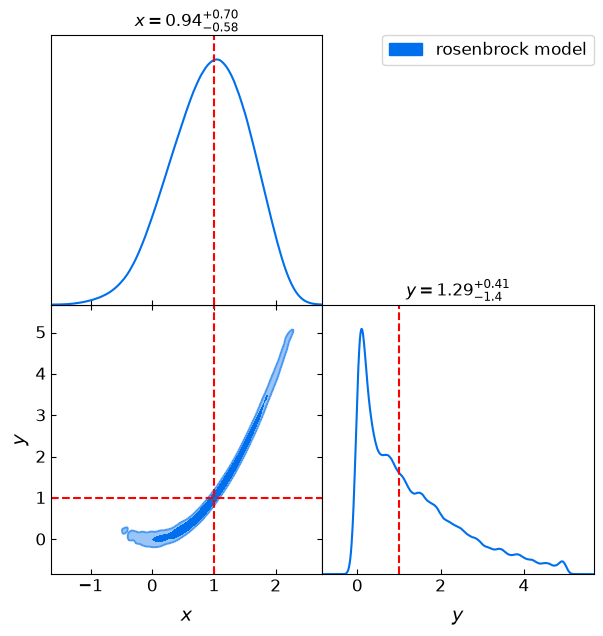

In [11]:
extract = CatalogExtract(name="rosenbrock model", cosmo=samples, truth_cosmo={"x": 1.0, "y": 1.0})
plot_posterior(extract)

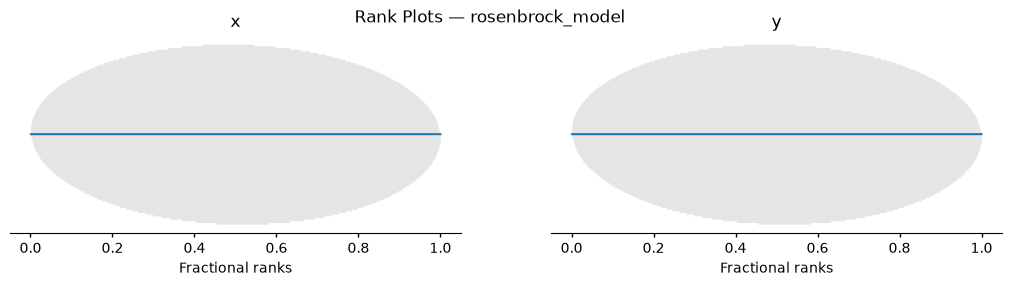

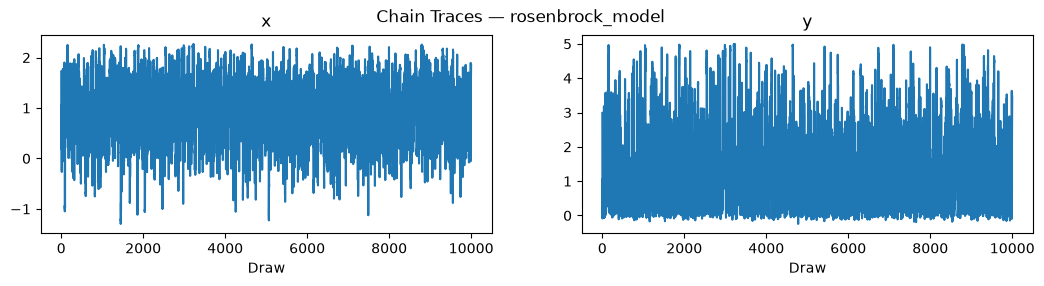

       mean        sd     ess_bulk  r_hat
x  0.940865  0.635517  1001.518173    NaN
y  1.289536  1.199930   995.294522    NaN


In [12]:
analyze(extract)